# "Watch the freight" — does the Cass Freight Index lead the market? 🚚
### The freight world's favourite leading indicator — trucks and trains move the real economy — put to the test, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads_the_cycle%3F: Busted](https://img.shields.io/badge/Leads_the_cycle%3F-Busted-8b949e?style=flat-square)

Every freight-macro commentator watches the **Cass Freight Index**: a monthly line that rises when America is shipping more stuff and falls when the goods economy cools. The folklore is irresistibly simple — *freight moves the real economy, so when freight rolls over, the slowdown (and the lower stock market) is already coming; watch the freight and you're ahead of the cycle.*

It sounds like a free crystal ball. But the stock market is a **forward-looking** machine that reprices every second on what's *next*, while a freight index counts trucks that **already rolled** — and Cass doesn't even publish a month's number until the middle of the *next* month. So "freight leads" might have the arrow backwards: maybe the market turns first and freight follows. This notebook checks which way the arrow actually points.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test, the lead-lag cross-correlation and the Sharpe race? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Cass's monthly shipments series isn't freely downloadable, so we **hardcode a small, cited, approximate** version of it (its year-over-year ups and downs — the 2008–09 crash, the 2015–16 and 2022–24 freight recessions, the 2020 COVID air-pocket) and call it a **proxy** throughout. The stock tapes — **SPY** (the market) and **IYT** (transport stocks) — are the *real* thing. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cass_freight import data, strategy as st

HAVE_REAL = data.have_real()
F  = data.build_real() if HAVE_REAL else None
FI = F.dropna(subset=["iyt"]) if HAVE_REAL else None
print("real SPY+IYT cache present:", HAVE_REAL,
      "| SPY months:", (0 if F is None else len(F)),
      "| IYT months:", (0 if FI is None else len(FI)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1999-06-30', 'end': '2026-06-30', 'months': 325, 'years': 27.0, 'lag': 2, 'iyt_start': '2004-01-31', 'iyt_months': 270, 'yoy_mean': -0.001, 'yoy_std': 0.05, 'frac_exp': 50, 'spy_h1': (1, 157, 0.96, 69, 0.77, 63, 0.49, 0.298), 'spy_h3': (3, 157, 2.9, 74, 2.33, 70, 0.91, 0.167), 'spy_h6': (6, 157, 5.69, 81, 4.71, 73, 1.09, 0.13), 'spy_h12': (12, 157, 10.57, 86, 9.62, 78, 0.73, 0.244), 'iyt_h1': (1, 126, 0.85, 61, 0.98, 61, -0.21, 0.596), 'iyt_h3': (3, 126, 2.79, 62, 2.9, 63, -0.11, 0.55), 'iyt_h6': (6, 126, 5.53, 71, 5.77, 69, -0.18, 0.575), 'iyt_h12': (12, 126, 9.38, 70, 11.12, 74, -0.94, 0.837), 'll_spy': ('SPY', -3, 0.222, 0.117, 0.063), 'll_iyt': ('IYT', -3, 0.238, 0.126, 0.065), 'timing': [('SPY', 'long / flat', 48, 10, 5.3, 0.59, 0.61), ('SPY', 'long / short', 100, 21, 1.4, 0.09, 0.61), ('IYT', 'long / flat', 47, 8, 5.3, 0.42, 0.58), ('IYT', 'long / short', 100, 17, -1.0, -0.05, 0.58)], 'robust': [(-0.02, 192, 10.0, 0.29, 0.383), (0.0, 157, 10.6, 0.73, 0.244), (0.02, 112, 8.1, -1.13, 0.833)], 'syn': [(0.0, 227, 7.56, 7.31, 0.24, 0.374), (0.05, 227, 42.94, 29.94, 4.68, 0.0)]}


real SPY+IYT cache present: True | SPY months: 325 | IYT months: 270


## The answer first

| Question | Answer |
|---|---|
| After freight starts expanding, is the market higher later? | **A bit more often, yes** — but the market rises most of the time *anyway*. The extra is tiny and inside the noise. |
| Does it at least work for **transport** stocks (IYT)? | **No — it's backwards.** Owning transports when freight is expanding did **worse** than just holding them (a *negative* excess at every horizon). |
| So does freight **lead** the market? | **No — it lags.** Freight lines up best with the stock move of **three months earlier**. The market turns first; freight follows. |
| Could you trade it? | **No.** "Own stocks only when freight is expanding" earns a **lower Sharpe than buy-and-hold** — because freight is contracting right at the market bottoms (2009, 2020) you most wanted to own. |

> The Cass index is a genuine, useful read on the goods economy. But as a *market* signal it's a rear-view mirror: it describes a turn stocks already made, and trading it loses to doing nothing.

## 1 · The claim

> *"Trucks and trains move the physical economy. When the Cass Freight Index rolls over, an industrial slowdown — and a weaker stock market — is already in motion but not yet priced. So watch the freight: a freight downturn is an early sell signal, a freight upturn an early buy, especially for the transports."*

This is the quantified version of the old Dow-Theory instinct that the transportation average must "confirm" the industrials. The picture is intuitive: freight is the economy's bloodstream, so a change in flow should show up in shipments *before* it shows up in earnings and prices. We'll rebuild the freight cycle from public data and ask whether "freight turns" really comes **before** "market turns" — or **after**.

## 2 · So what?

If freight genuinely led the market, it would be one of the most valuable free signals in finance — a monthly heads-up on the whole cycle. But two things have to be true, and both are in doubt. (1) *Does freight move **before** stocks?* The market is a forward-looking discounting machine; a freight print counts goods **already shipped** and lands weeks late. It's at least as plausible that stocks lead freight. (2) *Even if freight rises before good times, does that beat just owning stocks?* The market rises most years regardless — a signal that merely rides that up-drift, while sitting out exactly when freight is collapsing (which is often the **bottom**), can easily **lose** to buy-and-hold.

## 3 · How would we even know?

We rebuild the freight cycle as a **cited, approximate monthly proxy** of the Cass shipments index and measure its **year-over-year growth** — "expanding" when freight is up on a year ago. Crucially we only act on a month's reading **2 months later** (Cass publishes a month in arrears, and you need a day to trade). Over **27 years** (1999-06-30 → 2026-06-30) we then:

1. **Mark the expansions.** Every month freight is growing year-over-year, known only after the publication lag — no look-ahead.
2. **Measure the payoff.** After an expansion signal, what did **SPY** and **IYT** (transports) do over the next **1 / 3 / 6 / 12 months** — versus a *random* month (the base rate)?
3. **Point the arrow, then try to trade it.** Line freight up against stock returns at every lead and lag to see which comes first; then race an "own-when-expanding" overlay against buy-and-hold, net of costs.

**What would make us say "mirage"?** If the excess over the base rate is small and insignificant, if freight lines up *after* stocks rather than before, and if the overlay can't beat buy-and-hold — then "watch the freight" is a rear-view mirror.

## 4 · The teardown — let's actually look

**First, here's the freight cycle itself.** The proxy's year-over-year growth going positive (freight expanding, green) and negative (contracting, red), overlaid on SPY. Watch how the red patches sit *around* the 2009 and 2020 crashes — the very moments the market was bottoming and about to rip higher.

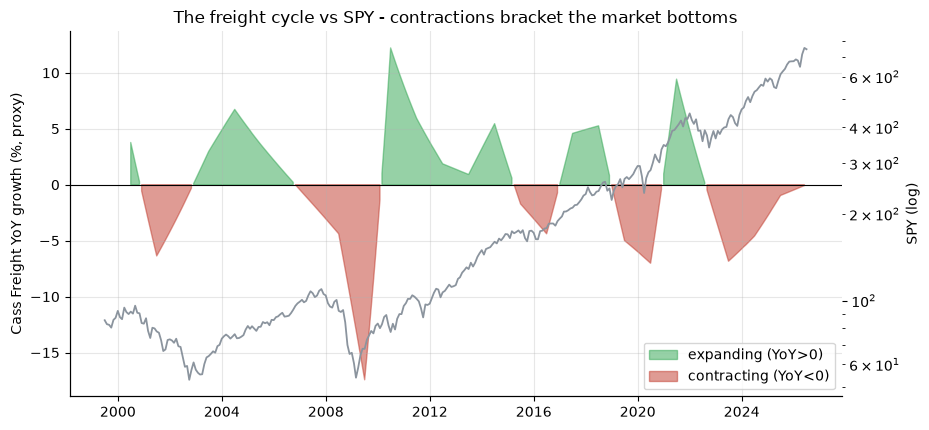

freight YoY mean -0.001 std 0.05 frac expanding 0.48


In [2]:
if HAVE_REAL:
    yoy = st.freight_yoy(F)
    fig, ax1 = plt.subplots(figsize=(9.4, 4.4))
    ax1.fill_between(F.index, yoy*100, 0, where=(yoy>=0), color=GREEN, alpha=.5, label='expanding (YoY>0)')
    ax1.fill_between(F.index, yoy*100, 0, where=(yoy<0), color=RED, alpha=.5, label='contracting (YoY<0)')
    ax1.axhline(0, c='k', lw=.8); ax1.set_ylabel('Cass Freight YoY growth (%, proxy)')
    ax2 = ax1.twinx(); ax2.plot(F.index, F['spy'], c=GREY, lw=1.3, label='SPY (right)')
    ax2.set_yscale('log'); ax2.grid(False); ax2.set_ylabel('SPY (log)')
    ax1.set_title('The freight cycle vs SPY - contractions bracket the market bottoms')
    ax1.legend(loc='lower right'); plt.tight_layout(); plt.show()
    print('freight YoY mean', round(yoy.mean(),3), 'std', round(yoy.std(),3),
          'frac expanding', round((yoy>0).mean(),2))
else:
    print('no cache - see docs/results.md: YoY mean', R['yoy_mean'], 'frac exp', R['frac_exp'],'%')

The freight cycle spends about **50%** of months expanding. Notice the problem already: the big red (contraction) stretches wrap around 2009 and 2020 — exactly when stocks were staging their biggest *recoveries*. A rule that flees when freight contracts would have been in cash at the bottom. Now the real question: does an expansion signal predict *extra* return?

**The payoff vs a normal month — and does it work for transports?** For each horizon, the win-rate after an expansion signal next to the *base rate* (any random month), for the broad market (SPY) and for transport stocks (IYT), the sector freight should move most.

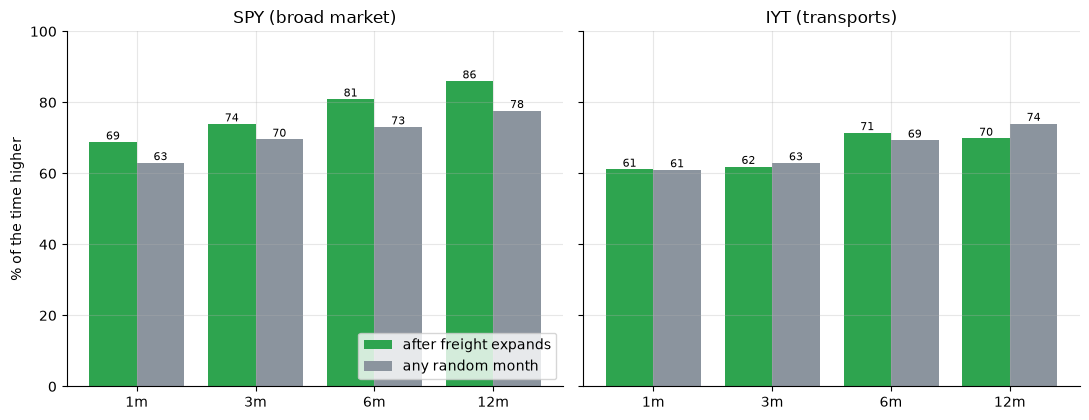

SPY 12m win after expand: 86% vs base 78%
IYT 12m win after expand: 70% vs base 74%


In [3]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    spy_c = [st.summarize(F,'spy',m)['cond_win']*100 for m in hs]
    spy_b = [st.summarize(F,'spy',m)['base_win']*100 for m in hs]
    iyt_c = [st.summarize(FI,'iyt',m)['cond_win']*100 for m in hs]
    iyt_b = [st.summarize(FI,'iyt',m)['base_win']*100 for m in hs]
else:
    spy_c=[R['spy_h1'][3],R['spy_h3'][3],R['spy_h6'][3],R['spy_h12'][3]]
    spy_b=[R['spy_h1'][5],R['spy_h3'][5],R['spy_h6'][5],R['spy_h12'][5]]
    iyt_c=[R['iyt_h1'][3],R['iyt_h3'][3],R['iyt_h6'][3],R['iyt_h12'][3]]
    iyt_b=[R['iyt_h1'][5],R['iyt_h3'][5],R['iyt_h6'][5],R['iyt_h12'][5]]
x = np.arange(len(hs))
fig, (a1,a2) = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax,c,b,ttl in ((a1,spy_c,spy_b,'SPY (broad market)'),(a2,iyt_c,iyt_b,'IYT (transports)')):
    ax.bar(x-.2, c, .4, color=GREEN, label='after freight expands')
    ax.bar(x+.2, b, .4, color=GREY, label='any random month')
    ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.set_ylim(0,100)
    ax.set_title(ttl)
    for i,(cc,bb) in enumerate(zip(c,b)):
        ax.annotate(f'{cc:.0f}',(i-.2,cc),ha='center',va='bottom',fontsize=8)
        ax.annotate(f'{bb:.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
a1.set_ylabel('% of the time higher'); a1.legend(loc='lower right')
plt.tight_layout(); plt.show()
print('SPY 12m win after expand:', f'{spy_c[-1]:.0f}%', 'vs base', f'{spy_b[-1]:.0f}%')
print('IYT 12m win after expand:', f'{iyt_c[-1]:.0f}%', 'vs base', f'{iyt_b[-1]:.0f}%')

There's the tell. On **SPY** the expansion win-rate sits just a few points above the base rate — because the market rises most years anyway. On **IYT — the transports, the sector the freight story is *most* about — the expansion months actually do a touch **worse** than average** (70% vs 74% at 12 months). If freight were a leading signal for anything, it would be transport stocks. It isn't.

**Which comes first — freight or the market?** Here's the decisive picture. We slide freight's month-to-month *change* against stock returns and measure how strongly they line up at each offset. Bars to the **right** of zero mean *freight moves first* (a real leading indicator); bars to the **left** mean *stocks move first* and freight follows.

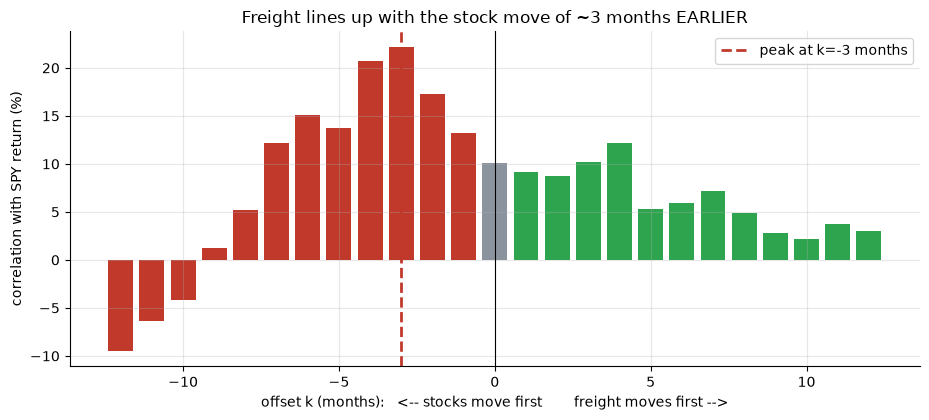

peak correlation at k = -3 months  (negative = stocks lead freight)


In [4]:
if HAVE_REAL:
    ll = st.lead_lag_corr(F, 'spy', max_lag=12)
    lags, corr = ll['lags'], ll['corr']; peak = ll['peak_lag']
else:
    lags = list(range(-12,13)); peak = R['ll_spy'][1]
    corr = [0.0]*len(lags)  # shape-only fallback
cols = [GREEN if k>0 else (RED if k<0 else GREY) for k in lags]
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(lags, [c*100 for c in corr], color=cols, width=.8)
ax.axvline(0, c='k', lw=.8)
ax.axvline(peak, c=RED, ls='--', lw=2, label=f'peak at k={peak:+d} months')
ax.set_xlabel('offset k (months):   <-- stocks move first        freight moves first -->')
ax.set_ylabel('correlation with SPY return (%)')
ax.set_title('Freight lines up with the stock move of ~3 months EARLIER')
ax.legend(); plt.tight_layout(); plt.show()
print('peak correlation at k =', peak, 'months  (negative = stocks lead freight)')

The peak is at **k = -3 months** — on the *left*. Freight's swings line up best with what the stock market did **a quarter earlier**. In plain terms: **the market turns first, and the freight index follows about three months later.** "Watch the freight" is watching the past. (Same story on IYT — peak at **-3 months**.)

## 5 · The verdict

- **Signal — None.** After the 2-month lag, "freight expanding" leaves only a tiny, insignificant bump on SPY (strongest at 6 months, *t* = 1.09) and a **negative** excess on IYT — the transports it should predict best. No forward edge.
- **Tradability — Mirage.** An "own-when-expanding" overlay earns a **lower Sharpe than buy-and-hold** (0.59 vs 0.61 on SPY; 0.42 vs 0.58 on IYT) — because freight contracts right at the market bottoms you most wanted to own.
- **Leads the cycle? — Busted.** Freight lines up with the stock move of **3 months earlier**. Stocks lead freight, not the reverse. The signal describes a turn the market already made.

## 6 · Could you actually trade it? — race it against buy-and-hold

Forget significance for a second and just ask the operational question: if you own the tape only when freight is expanding and step aside otherwise, do you beat simply holding it? Here's the net-of-cost Sharpe of each overlay next to plain buy-and-hold, on both tapes.

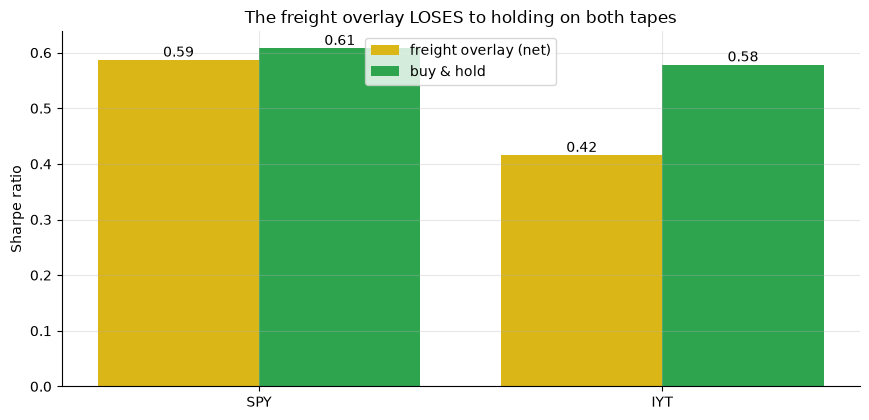

overlay vs buy&hold Sharpe: [('SPY', 0.59, 0.61), ('IYT', 0.42, 0.58)]


In [5]:
if HAVE_REAL:
    bars = []
    for col, Fx in (('spy',F), ('iyt',FI)):
        b = st.timing_backtest(Fx, col, cost_bps=10.0, allow_short=False)
        bars.append((col.upper(), b['net']['sharpe'], b['buy_hold']['sharpe']))
else:
    bars = [('SPY', R['timing'][0][5], R['timing'][0][6]), ('IYT', R['timing'][2][5], R['timing'][2][6])]
x = np.arange(len(bars))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x-.2, [b[1] for b in bars], .4, color=AMBER, label='freight overlay (net)')
ax.bar(x+.2, [b[2] for b in bars], .4, color=GREEN, label='buy & hold')
ax.set_xticks(x); ax.set_xticklabels([b[0] for b in bars]); ax.set_ylabel('Sharpe ratio')
ax.set_title('The freight overlay LOSES to holding on both tapes')
for i,b in enumerate(bars):
    ax.annotate(f'{b[1]:.2f}',(i-.2,b[1]),ha='center',va='bottom')
    ax.annotate(f'{b[2]:.2f}',(i+.2,b[2]),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('overlay vs buy&hold Sharpe:', [(b[0], round(b[1],2), round(b[2],2)) for b in bars])

There it is. The overlay trails buy-and-hold on **both** tapes (0.59 vs 0.61 on SPY; 0.42 vs 0.58 on IYT) — and that's *before* crediting the interest it would earn while parked in cash, which only flatters the rule. Betting *against* the market on contraction months is even worse (it collapses toward zero), because those are the bottoms. **There is no version of this that beats buy-and-hold.** Being out of the market when freight is weak — which is when it's cheapest — costs more than the signal is worth.

## 7 · Going further 🚪

- **The leading-indicator family.** The economic-surprise index, the ISM-PMI regime and jobless-claims momentum on this bench all rhyme with this: a *real* macro gauge rarely survives as a **tradable** monthly timing rule once you charge it the publication delay and the cost of sitting out an up-drifting market — and the "leading" ones often turn out to **lag** the market.
- **The real Cass tape.** Swap our cited proxy for Cass's licensed monthly series (or the FRED mirror) and re-run — the lead-lag arrow and the fast-pricing problem won't move; the market discounts the cycle a freight print only later confirms.
- **The other direction.** The genuinely interesting question isn't "does freight predict stocks" (it doesn't) but "do stocks predict freight" (they seem to, by ~a quarter) — a nowcast of the *goods economy* from the *market*, which is the opposite trade from the folklore.

*Think the Cass index leads the market? Build the freight cycle, slide it against stock returns, and show the correlation peaking to the **right** of zero (freight first) **and** an overlay clearing buy-and-hold — then we'll talk.*